In [ ]:
# Trying to modify the parameter 'a_alpha' in the quartic potential
# 'A. Support function optimization' in 'IV. Self-consistent cycle' in https://doi.org/10.1063/1.4871876

In [1]:
# Initial setting

from os import environ, system, path
from BigDFT.Calculators import SystemCalculator
from BigDFT.Inputfiles import Inputfile
from BigDFT.Database.Molecules import get_molecule
from BigDFT.IO import read_xyz

In [2]:
environ["BIGDFT_ROOT"] = "/home/elliot/Softwares/bigdft_cube_elliot/build/install/bin"

In [3]:
!mpirun --version

mpirun (Open MPI) 5.0.7

Report bugs to https://www.open-mpi.org/community/help/


In [8]:
calc = SystemCalculator(omp=16, mpi_run='mpirun -np 1')

Initialize a Calculator with OMP_NUM_THREADS=16 and command mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft


In [9]:
log = {}

In [10]:
with open ('si3o6.xyz','r') as ifile:
    struc = read_xyz(ifile)

In [11]:
# Standard Calculation

inp = Inputfile()
inp["import"]="linear"
inp.set_hgrid(0.45) 
inp.set_xc('PBE')
inp.set_psp_nlcc()
inp["lin_general"] = {"support_function_multipoles": True}
inp["lin_general"] = {"output_wf": 21}

log['std_full_calc'] = calc.run(sys=struc, input=inp, name='calc', run_dir='std_full', skip=True)

Creating the yaml input file "std_full/calc.yaml"
Run directory std_full
Executing command:  mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft -n calc -s Yes
 <BigDFT> Run already performed, found final file: forces_calc.yaml
 Memory Consumption Report:
   Tot. No. of Allocations:  0
   Tot. No. of Deallocations:  0
   Remaining Memory (B):  0
   Memory occupation:
     Peak Value (MB):  0.000
     for the array: null
     in the routine: null
     Memory Peak of process: 28.728 MB
 Walltime since initialization:  00:00:00.073565886
 Max No. of dictionaries used:  1106 #( 1040 still in use)
 Number of dictionary folders allocated:  1


In [16]:
# Turn off the SF optimization only

no_SFopt_inp = Inputfile()
no_SFopt_inp["import"] = "linear"
no_SFopt_inp.set_hgrid(0.55)
no_SFopt_inp.set_xc("PBE")
no_SFopt_inp.set_psp_nlcc()
no_SFopt_inp["perf"] = {"adjust_kernel_iterations": False,
                    "adjust_kernel_threshold": False}

no_SFopt_inp["lin_general"] = {"hybrid": False, "nit": [0,1], 'output_wf': 21}
no_SFopt_inp["lin_basis"] = {"nit": 1, "idsx": 0}
no_SFopt_inp["lin_kernel"] = {"nit": 100, "rpnrm_cv": 1.0e-11, "delta_pnrm": -1} 

no_SFopt_inp['dft'] = {'itermax': 0, 'output_denspot': 21}

log['std_no_SFopt'] = calc.run(sys=struc, input=no_SFopt_inp, name='calc', run_dir='std_no_SFopt', skip=True)

Creating the yaml input file "std_no_SFopt/calc.yaml"
Run directory std_no_SFopt
Executing command:  mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft -n calc -s Yes
 <BigDFT> Run already performed, found final file: forces_calc.yaml
 Memory Consumption Report:
   Tot. No. of Allocations:  0
   Tot. No. of Deallocations:  0
   Remaining Memory (B):  0
   Memory occupation:
     Peak Value (MB):  0.000
     for the array: null
     in the routine: null
     Memory Peak of process: 28.288 MB
 Walltime since initialization:  00:00:00.074318624
 Max No. of dictionaries used:  1106 #( 1040 still in use)
 Number of dictionary folders allocated:  1


In [17]:
# a_alpha = 0.2, turn off the SF optimization

from copy import deepcopy

con_02_no_SFopt_inp = deepcopy(no_SFopt_inp)

con_02_no_SFopt_inp["lin_basis_params"] = {"ao_confinement": 0.2}

log['con_0.2_no_SFopt'] = calc.run(sys=struc, input=con_02_no_SFopt_inp, name='calc', run_dir='con_02_no_SFopt', skip=True)

Creating the yaml input file "con_02_no_SFopt/calc.yaml"
Run directory con_02_no_SFopt
Executing command:  mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft -n calc -s Yes
 <BigDFT> Run already performed, found final file: forces_calc.yaml
 Memory Consumption Report:
   Tot. No. of Allocations:  0
   Tot. No. of Deallocations:  0
   Remaining Memory (B):  0
   Memory occupation:
     Peak Value (MB):  0.000
     for the array: null
     in the routine: null
     Memory Peak of process: 28.228 MB
 Walltime since initialization:  00:00:00.075117244
 Max No. of dictionaries used:  1106 #( 1040 still in use)
 Number of dictionary folders allocated:  1


In [14]:
# Standard procedure to get Initial Atomic Orbital

ao_inp = Inputfile()
ao_inp["import"] = "linear"
ao_inp.set_hgrid(0.55)
ao_inp.set_xc("PBE")
ao_inp.set_psp_nlcc()

ao_inp["lin_basis"] = {"orthogonalize_ao": False, "orthogonalize_sfs": False,
                    "extended_ig": False, "nit": 1, "idsx": 0}

ao_inp["perf"] = {"experimental_mode": False, 
               "adjust_kernel_iterations": False, 
               "adjust_kernel_threshold": False}

ao_inp["lin_general"] = {"hybrid": False, "nit": 0, 'output_wf': 21, "output_wf": 21}
ao_inp["lin_kernel"] = {"nit": 0, "rpnrm_cv": 1.0e-11, "delta_pnrm": -1}
ao_inp['dft'] = {'itermax': 0, 'output_denspot': 21}

log['std_AO'] = calc.run(sys=struc, input=ao_inp, name='calc', run_dir='std_AO', skip=True)

Creating the yaml input file "std_AO/calc.yaml"
Run directory std_AO
Executing command:  mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft -n calc -s Yes
 <BigDFT> Run already performed, found final file: forces_calc.yaml
 Memory Consumption Report:
   Tot. No. of Allocations:  0
   Tot. No. of Deallocations:  0
   Remaining Memory (B):  0
   Memory occupation:
     Peak Value (MB):  0.000
     for the array: null
     in the routine: null
     Memory Peak of process: 28.508 MB
 Walltime since initialization:  00:00:00.074224565
 Max No. of dictionaries used:  1106 #( 1040 still in use)
 Number of dictionary folders allocated:  1


In [18]:
# a_alpha = 0.2, get the Initial Atomic Orbital

con_02_AO_inp = deepcopy(ao_inp)

con_02_AO_inp["lin_basis_params"] = {"ao_confinement": 0.2}

log['con_0.2_AO'] = calc.run(sys=struc, input=con_02_AO_inp, name='calc', run_dir='con_02_AO', skip=True)

Creating the yaml input file "con_02_AO/calc.yaml"
Run directory con_02_AO
Executing command:  mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft -n calc -s Yes
 <BigDFT> Run already performed, found final file: forces_calc.yaml
 Memory Consumption Report:
   Tot. No. of Allocations:  0
   Tot. No. of Deallocations:  0
   Remaining Memory (B):  0
   Memory occupation:
     Peak Value (MB):  0.000
     for the array: null
     in the routine: null
     Memory Peak of process: 28.188 MB
 Walltime since initialization:  00:00:00.075557249
 Max No. of dictionaries used:  1106 #( 1040 still in use)
 Number of dictionary folders allocated:  1


In [22]:
# a_alpha = 0.2, restart the calculation from AO, in wavelet way

system('cp -r con_02_AO/ con_02_AO_RE_wavelet_no_SFopt')
system(f'rm con_02_AO_RE_wavelet_no_SFopt/*.yaml con_02_AO_RE_wavelet_no_SFopt/*.bib')

con_02_AO_RE_wavelet_inp = deepcopy(con_02_no_SFopt_inp)
con_02_AO_RE_wavelet_inp["dft"]["inputpsiid"] = "linear_restart"

log['con_0.2_AO_RE_wavelet_no_SFopt'] = calc.run(sys=struc, input=con_02_AO_RE_wavelet_inp, name='calc', run_dir='con_02_AO_RE_wavelet_no_SFopt', skip=True)

Creating the yaml input file "con_02_AO_RE_wavelet_no_SFopt/calc.yaml"
Run directory con_02_AO_RE_wavelet_no_SFopt
Executing command:  mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft -n calc -s Yes
 <BigDFT> log of the run will be written in logfile: ./log-calc.yaml


In [25]:
# a_alpha = 0.2, restart the calculation from AO, in cubefile way

system(f'cp -r con_02_AO/ con_02_AO_RE_cube_no_SFopt/')
system(f'rm con_02_AO_RE_cube_no_SFopt/*.yaml con_02_AO_RE_cube_no_SFopt/*.bib')

with open("./std_no_SFopt//data-calc/minBasis.yaml") as ifile:
    with open(f"./con_02_AO_RE_cube_no_SFopt/data-calc/minBasis.yaml", "w") as ofile:
        for line in ifile:
            if "- function" in line:
                continue
            ofile.write(line.replace("  function (global cube)", "- function (global cube)"))

con_02_AO_RE_cube_inp = deepcopy(con_02_no_SFopt_inp)
con_02_AO_RE_cube_inp["dft"]["inputpsiid"] = "linear_restart"

log['con_0.2_AO_RE_cube_no_SFopt'] = calc.run(sys=struc, input=con_02_AO_RE_cube_inp, name='calc', run_dir='con_02_AO_RE_cube_no_SFopt', skip=True)

Creating the yaml input file "con_02_AO_RE_cube_no_SFopt/calc.yaml"
Run directory con_02_AO_RE_cube_no_SFopt
Executing command:  mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft -n calc -s Yes
 <BigDFT> log of the run will be written in logfile: ./log-calc.yaml
ERROR in dgetrf, info=4. Set determinant to zero.


In [26]:
# a_alpha = 0.2
# Turn off experimental mode, orthogonalization
# Turn off Supprot Function optimization
# Let the calculation go

con_02_AO_std_inp = Inputfile()
con_02_AO_std_inp["import"] = "linear"
con_02_AO_std_inp.set_hgrid(0.55)
con_02_AO_std_inp.set_xc("PBE")
con_02_AO_std_inp.set_psp_nlcc()

con_02_AO_std_inp["lin_basis"] = {"orthogonalize_ao": False, "orthogonalize_sfs": False,
                    "extended_ig": False, "nit": 1, "idsx": 0}

con_02_AO_std_inp["lin_basis_params"] = {"ao_confinement": 0.2}

con_02_AO_std_inp["perf"] = {"experimental_mode": False, 
               "adjust_kernel_iterations": False, 
               "adjust_kernel_threshold": False}

con_02_AO_std_inp["lin_general"] = {"hybrid": False, "nit": [0,1], 'output_wf': 21}
con_02_AO_std_inp["lin_kernel"] = {"nit": 100, "rpnrm_cv": 1.0e-11, "delta_pnrm": -1} 
con_02_AO_std_inp['dft'] = {'itermax': 0, 'output_denspot': 21}

log['con_0.2_AO_std_no_SFopt'] = calc.run(sys=struc, input=con_02_AO_std_inp, name='calc', run_dir='con_02_AO_std_no_SFopt', skip=True)

Create the sub-directory 'con_02_AO_std_no_SFopt'
Creating the yaml input file "con_02_AO_std_no_SFopt/calc.yaml"
Run directory con_02_AO_std_no_SFopt
Executing command:  mpirun -np 1 /home/elliot/Softwares/bigdft_cube_elliot/build/install/bin/bigdft -n calc -s Yes
 <BigDFT> log of the run will be written in logfile: ./log-calc.yaml
ERROR in dgetrf, info=4. Set determinant to zero.


In [ ]:
# Visualize the iteration process

In [31]:
def plot_iterations(log_name):
    from matplotlib import pyplot as plt
    fig, axs = plt.subplots(1, 1, figsize=(10,6), dpi=120)
    for k, v in log_name.items():
        # axs.plot([abs(x - log['normal'].energy) for x in v.get_intermediate_energies()], 'o--', label=k)
        axs.plot([x for x in v.get_intermediate_energies()], '-', label=k, alpha=0.65)
        axs.set_xlabel("Iteration")
        axs.set_ylabel("Energy Convergence")
        axs.legend()
        # axs.set_yscale("log")

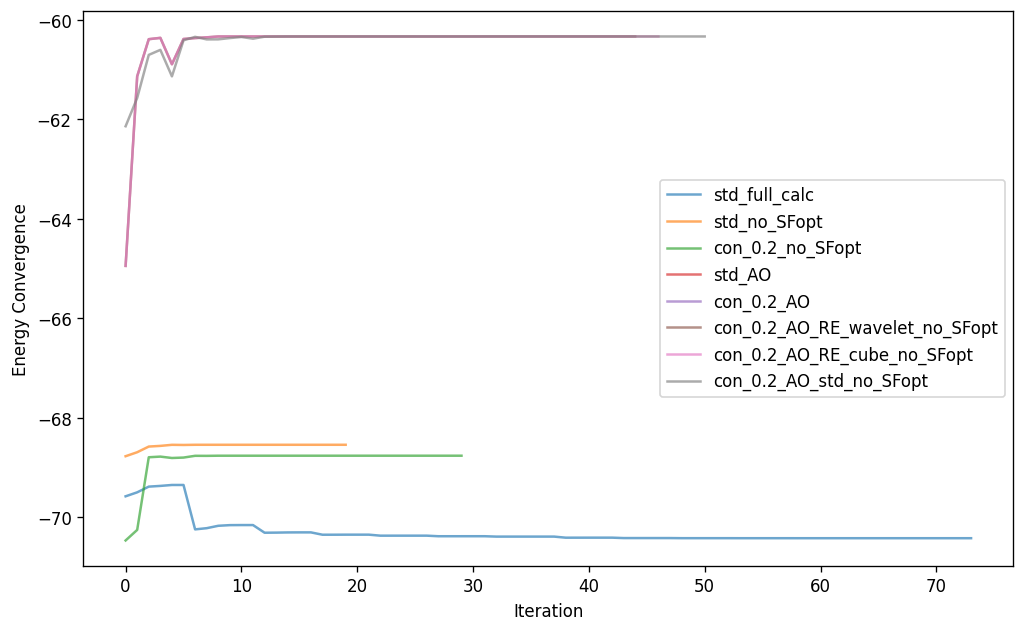

In [32]:
plot_iterations(log)

In [33]:
log_RE = {}
log_RE['con_0.2_AO_RE_wavelet_no_SFopt'] = log['con_0.2_AO_RE_wavelet_no_SFopt']
log_RE['con_0.2_AO_RE_cube_no_SFopt'] = log['con_0.2_AO_RE_cube_no_SFopt']
log_RE['con_0.2_AO_std_no_SFopt'] = log['con_0.2_AO_std_no_SFopt']

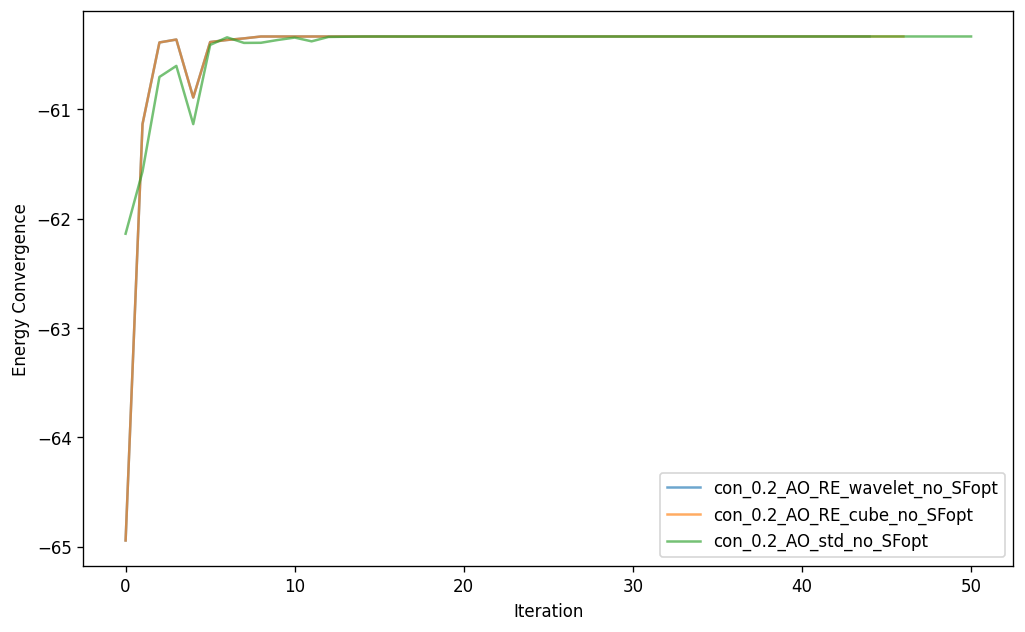

In [ ]:
# The curves 'con_0.2_AO_RE_wavelet_no_SFopt' 
# and 'con_0.2_AO_RE_cube_no_SFopt' are totally overlaped.

plot_iterations(log_RE)